# Домашнее задание "Центральная предельная теорема и статистика".

## Задание.

В этом задании нужно убедиться, что ЦПТ действительно работает.

Создайте случайную величину из [любого выбранного вами распределения](https://docs.scipy.org/doc/scipy/reference/stats.html), для разных значений `n` сгенерируйте 1000 выборок размера `n`. Постройте гистрограммы средних этих выборок и сделайте выводы.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sts
%matplotlib inline

In [ ]:
# Двойная случайная величина Вейбулла, непрерывная случайная величина.
# задаем параметр формы с - при значении 2 распределение становится
# двойным распределением Рэлея
с = 2
rv = sts.dweibull(с)
sample = rv.rvs(size=1000)

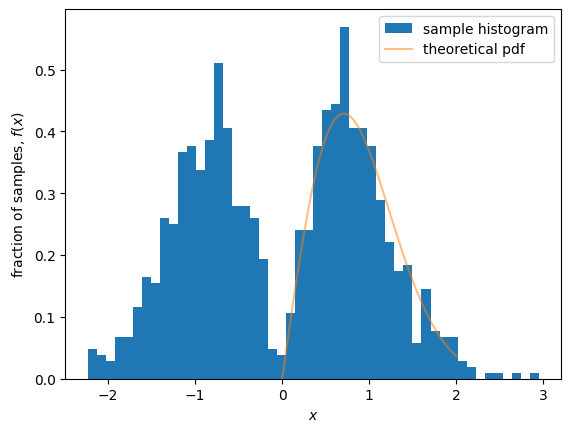

In [ ]:
x = np.linspace(0,2,100)
pdf = rv.pdf(x)
plt.hist(sample, density=True, bins=50, label='sample histogram')
plt.plot(x, pdf, label='theoretical pdf', alpha=0.5)
plt.legend()
plt.ylabel('fraction of samples, $f(x)$')
plt.xlabel('$x$')
plt.show()

In [ ]:
# Размеры выборок
n1 = 2
n2 = 10
n3 = 20

# Массивы для сохранения средних по выборкам
a1 = np.array([])
a2 = np.array([])
a3 = np.array([])

# Количество повторов генерации
samples_count = 1000

for number in range(samples_count):
    # На каждом цикле генерируем выборки указанных размеров
    sample1 = rv.rvs(size=n1)
    sample2 = rv.rvs(size=n2)
    sample3 = rv.rvs(size=n3)

    # Считаем среднее по каждой выборке и добавляем в массив средних
    a1 = np.append(a1, sample1.mean())
    a2 = np.append(a2, sample2.mean())
    a3 = np.append(a3, sample3.mean())

Text(0.5, 0, '$x$')

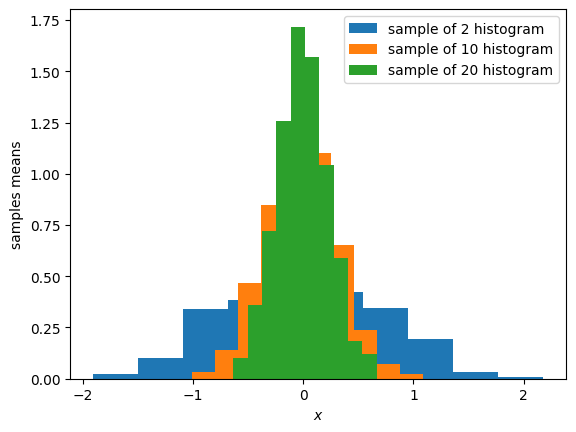

In [ ]:
# Подписи для графиков
label_1 = f'sample of {str(n1)} histogram'
label_2 = f'sample of {str(n2)} histogram'
label_3 = f'sample of {str(n3)} histogram'

# Строим графики
plt.hist(a1, density=True, label=label_1)
plt.hist(a2, density=True, label=label_2)
plt.hist(a3, density=True, label=label_3)

plt.legend()
plt.ylabel('samples means')
plt.xlabel('$x$')

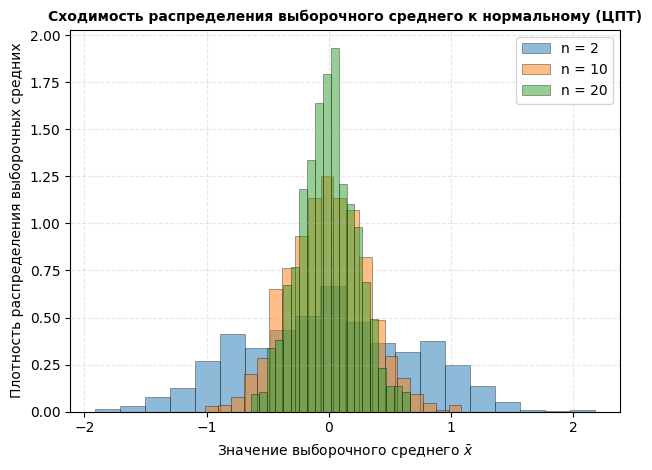

In [ ]:
# улучшенная визуализация

# Подписи для графиков
label_1 = f'n = {str(n1)}'
label_2 = f'n = {str(n2)}'
label_3 = f'n = {str(n3)}'

# Строим гистограммы для распределения выборочных средних
plt.hist(a1, density=True, label=label_1, alpha=0.5, bins=20, edgecolor='black', linewidth=0.5)
plt.hist(a2, density=True, label=label_2, alpha=0.5, bins=20, edgecolor='black', linewidth=0.5)
plt.hist(a3, density=True, label=label_3, alpha=0.5, bins=20, edgecolor='black', linewidth=0.5)

# Настройка подписей осей
plt.ylabel('Плотность распределения выборочных средних', fontsize=10)
plt.xlabel('Значение выборочного среднего $\\bar{x}$', fontsize=10)

# Остальные настройки
plt.legend(loc='upper right', fontsize=10)
plt.grid(alpha=0.3, linestyle='--')
plt.title('Сходимость распределения выборочного среднего к нормальному (ЦПТ)', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# ВЫВОДЫ.

При увеличении размера выборки (n1 → n2 → n3) распределение выборочных средних:

1. Стремится к нормальному распределению (подтверждение ЦПТ)

2. Стандартное отклонение уменьшается (σ/√n) — гистограмма становится уже

3. Центр группируется вокруг математического ожидания исходного распределения

*Независимо от формы исходного распределения, распределение выборочного среднего стремится к нормальному при n → ∞*